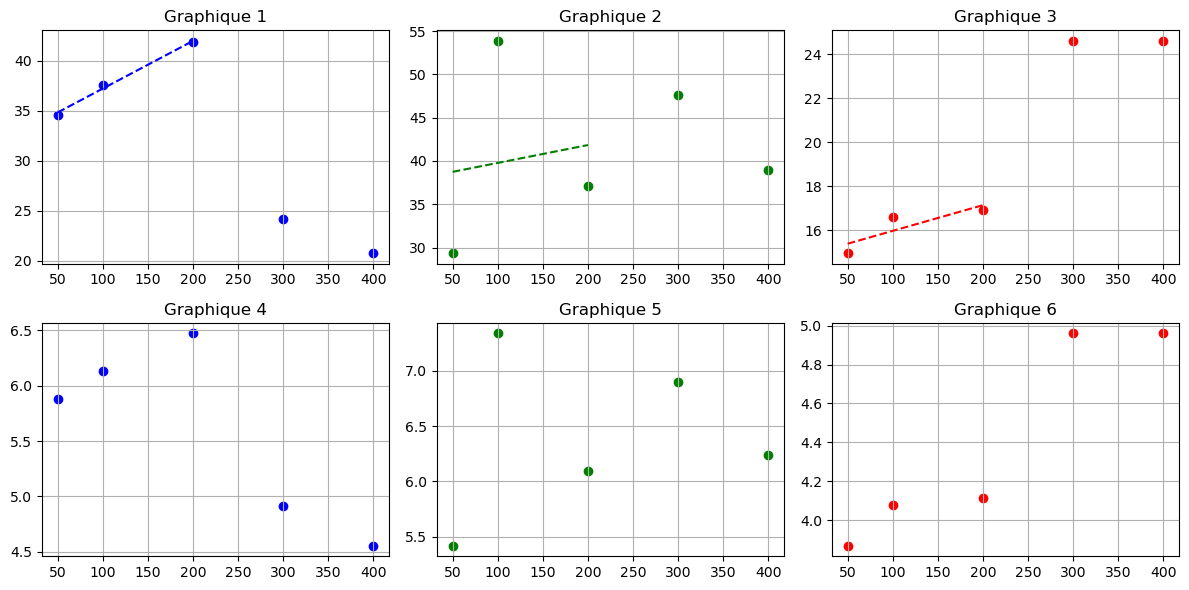

In [1]:
import numpy as np
import matplotlib.pyplot as plt

amplitude = np.array([50,100,200,300,400]) # en mV

# -- liste des batch --

batch_155 = np.array([34.571,37.612,41.861,24.146,20.745])
sqrt_155 = np.array([5.879,6.132,6.472,4.914,4.555])

batch_310 = np.array([29.347,53.855,37.138,47.633,38.918])
sqrt_310 = np.array([5.417,7.340,6.096,6.902,6.237])

batch_465 = np.array([14.965,16.623,16.93,24.601,24.601])
sqrt_465 = np.array([3.868,4.077,4.115,4.960,4.960])

# -- regression linéaire --
#fit_155 = np.polyfit(amplitude, batch_155, 1)
fit_155 = np.polyfit(amplitude[0:3], batch_155[0:3], 1)
a_155 = fit_155[0]
b_155 = fit_155[1]

fit_310 = np.polyfit(amplitude[0:3], batch_310[0:3], 1)
a_310 = fit_310[0]
b_310 = fit_310[1]

fit_465 = np.polyfit(amplitude[0:3], batch_465[0:3], 1)
a_465 = fit_465[0]
b_465 = fit_465[1]

# -- affichages des graphiques --
plt.figure(figsize=(12, 6)) 

plt.subplot(2, 3, 1)
plt.scatter(amplitude, batch_155, label='Batch 155', color='blue')
plt.plot(amplitude[0:3], a_155 * amplitude[0:3] + b_155, color='blue', linestyle='--', label='Régression Batch 155')
plt.title("Graphique 1")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.scatter(amplitude, batch_310, label='Batch 310', color='green')
plt.plot(amplitude[0:3], a_310 * amplitude[0:3] + b_310, color='green', linestyle='--', label='Régression Batch 310')
plt.title("Graphique 2")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.scatter(amplitude, batch_465, label='Batch 465', color='red')
plt.plot(amplitude[0:3], a_465 * amplitude[0:3] + b_465, color='red', linestyle='--', label='Régression Batch 465')
plt.title("Graphique 3")
plt.grid(True)

plt.subplot(2, 3, 4)
plt.scatter(amplitude, sqrt_155, label='Batch 155', color='blue')
plt.title("Graphique 4")
plt.grid(True)

plt.subplot(2, 3, 5)
plt.scatter(amplitude, sqrt_310, label='Batch 310', color='green')
plt.title("Graphique 5")
plt.grid(True)

plt.subplot(2, 3, 6)
plt.scatter(amplitude, sqrt_465, label='Batch 465', color='red')
plt.title("Graphique 6")
plt.grid(True)

plt.tight_layout() 

plt.show()

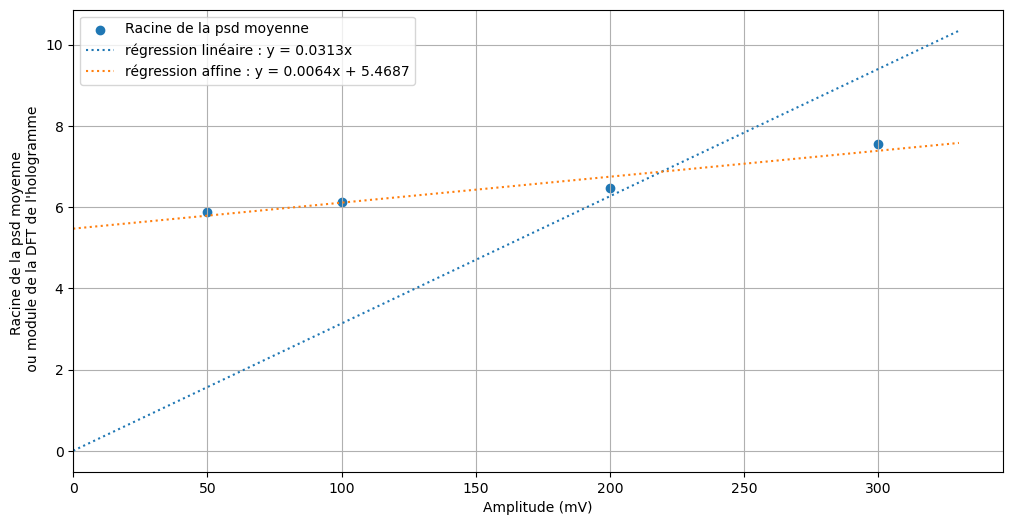

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Batch_155 = np.array([34.571, 37.612, 41.861, 56.985])
batch_155 = np.sqrt(Batch_155)
amplitude = np.array([50, 100, 200, 300])  # même nombre de points

def linear(x, a):
    return a*x
popt, pcov = curve_fit(linear, amplitude, batch_155)
a = popt[0]

def affine(x, b,c):
    return(b*x+c)
popt2,pcov2 = curve_fit(affine, amplitude, batch_155)
b,c = popt2
# Tracé

xfit = np.linspace(0, amplitude.max()*1.1, 100)

plt.figure(figsize=(12, 6)) 
plt.scatter(amplitude, batch_155, label="Racine de la psd moyenne")
plt.plot(xfit, linear(xfit, a),linestyle=':',label=f"régression linéaire : y = {a:.4f}x")
plt.plot(xfit, affine(xfit,b,c),linestyle=':',label=f"régression affine : y = {b:.4f}x + {c:.4f}")
plt.xlim(left=0)
plt.grid(True)
plt.xlabel("Amplitude (mV)")
plt.ylabel("Racine de la psd moyenne \n ou module de la DFT de l'hologramme")
plt.legend()
plt.show()